# Easter Period Analysis & Demand Forecast
## Foodland Wudinna — Fruit & Vegetable Department

**Scope:** Three-week window around Easter for both 2025 (actual) and 2026 (forecast).

**Easter 2025:** Sunday 20 April 2025  
**Easter 2026:** Sunday 5 April 2026

| | Easter 2025 | Easter 2026 |
|---|---|---|
| Good Friday | 18 Apr | 3 Apr |
| Easter Saturday | 19 Apr (OPEN) | 4 Apr (CLOSED) |
| Easter Sunday | 20 Apr (CLOSED) | 5 Apr (CLOSED) |
| Easter Monday | 21 Apr (CLOSED) | 6 Apr (CLOSED) |
| Reopening | Tue 22 Apr | Tue 7 Apr |

**Key difference 2026:** The store will close from Friday through Monday (4 consecutive days), compared to 2025 where Easter Saturday was still open. This means the pre-Easter surge must cover one extra day of customer demand, and the post-Easter restock period has different dynamics.

**Additional note (2025):** ANZAC Day (25 Apr) fell on Friday the week after Easter, creating a second closure. This won't repeat in the same pattern in 2026.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

NAVY = '#1F3864'
GREEN = '#1E7145'
AMBER = '#BF8F00'
RED = '#C00000'
LGREY = '#F0F0F0'

# Load data
df25 = pd.read_csv('sales_fruit_2025.csv', parse_dates=['Date'])
df26 = pd.read_csv('sales_fruit_2026.csv', parse_dates=['Date'])

for d in [df25, df26]:
    d['date'] = d['Date'].dt.normalize()
    d['dow'] = d['date'].dt.day_name()
    d['Name'] = d['Name'].str.strip().str.replace('\n', ' ')

dfall = pd.concat([df25, df26], ignore_index=True)

print(f'2025 data: {df25["date"].min().date()} to {df25["date"].max().date()} ({df25["date"].nunique()} trading days)')
print(f'2026 data: {df26["date"].min().date()} to {df26["date"].max().date()} ({df26["date"].nunique()} trading days)')

2025 data: 2025-01-02 to 2025-12-31 (308 trading days)
2026 data: 2026-01-01 to 2026-03-19 (66 trading days)


---
## 1. Easter 2025 — Day-by-Day Revenue Flow

The chart below shows the full three-week window (7 Apr – 26 Apr 2025) with closure days marked in red. The key pattern is a dramatic demand build-up in the three days before Good Friday, followed by a softer recovery after reopening.

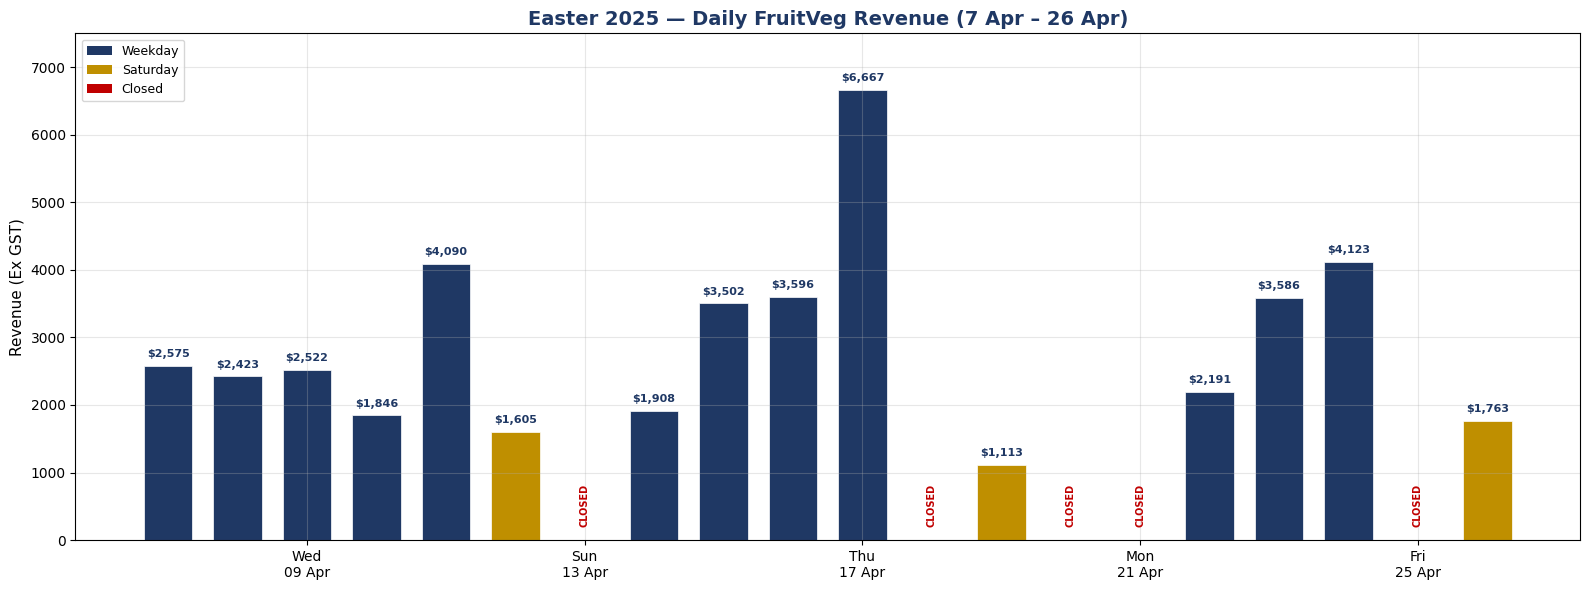

In [2]:
# Build day-by-day data for the 3-week Easter 2025 window
easter_period_25 = df25[(df25['date'] >= '2025-04-07') & (df25['date'] <= '2025-04-26')]
daily25 = easter_period_25.groupby('date').agg(
    Revenue=('Sales Ex GST','sum'), GP=('GP $','sum'),
    Lines=('Lines','sum'), Quantity=('Quantity','sum'),
    Items=('Name','nunique')
).reset_index()
daily25['dow'] = daily25['date'].dt.day_name()
daily25['GP_pct'] = (daily25['GP'] / daily25['Revenue'] * 100).round(1)

# Add closure days
import datetime
closures_25 = [datetime.date(2025,4,13), datetime.date(2025,4,18),
               datetime.date(2025,4,20), datetime.date(2025,4,21), datetime.date(2025,4,25)]
for c in closures_25:
    ct = pd.Timestamp(c)
    if ct not in daily25['date'].values:
        daily25 = pd.concat([daily25, pd.DataFrame({
            'date':[ct],'Revenue':[0],'GP':[0],'Lines':[0],'Quantity':[0],
            'Items':[0],'dow':[ct.day_name()],'GP_pct':[0]
        })], ignore_index=True)
daily25 = daily25.sort_values('date').reset_index(drop=True)

# Plot
fig, ax = plt.subplots(figsize=(16, 6))
colors = [RED if r['Revenue']==0 else (AMBER if r['dow']=='Saturday' else NAVY) for _,r in daily25.iterrows()]
bars = ax.bar(daily25['date'], daily25['Revenue'], color=colors, width=0.7, edgecolor='white', linewidth=0.5)

# Annotate
for _, r in daily25.iterrows():
    if r['Revenue'] > 0:
        ax.text(r['date'], r['Revenue'] + 100, f"${r['Revenue']:,.0f}", ha='center', va='bottom',
                fontsize=8, fontweight='bold', color=NAVY)
    else:
        ax.text(r['date'], 200, 'CLOSED', ha='center', va='bottom',
                fontsize=7, fontweight='bold', color=RED, rotation=90)

ax.set_ylabel('Revenue (Ex GST)', fontsize=11)
ax.set_title('Easter 2025 — Daily FruitVeg Revenue (7 Apr – 26 Apr)', fontsize=14, fontweight='bold', color=NAVY)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%a\n%d %b'))
ax.set_ylim(0, 7500)

# Legend
legend_elements = [
    mpatches.Patch(facecolor=NAVY, label='Weekday'),
    mpatches.Patch(facecolor=AMBER, label='Saturday'),
    mpatches.Patch(facecolor=RED, label='Closed'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('easter_2025_daily_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

### Key observations from Easter 2025

**Pre-Easter surge:** Thursday 17 April (the day before Good Friday) recorded **$6,667** in revenue — that's **3.3× a normal April Thursday** ($2,023). The build-up started on Tuesday and intensified each day:

| Day | Revenue | vs Normal DOW | Multiplier |
|-----|---------|---------------|------------|
| Mon 14 Apr | $1,908 | $2,575 | 0.74× (below normal) |
| Tue 15 Apr | $3,502 | $2,526 | 1.39× |
| Wed 16 Apr | $3,596 | $2,362 | 1.52× |
| **Thu 17 Apr** | **$6,667** | **$2,023** | **3.30×** |
| Sat 19 Apr (Easter) | $1,113 | $1,294 | 0.86× |

**Post-Easter recovery:** The reopening Tuesday was **below normal** (0.87×), but Wednesday and Thursday bounced strongly — likely driven by customers restocking after the long weekend. Note that Thursday 24 Apr was also elevated because it was ANZAC Day eve (another closure the next day).

| Day | Revenue | vs Normal DOW | Multiplier |
|-----|---------|---------------|------------|
| Tue 22 Apr (reopen) | $2,191 | $2,526 | 0.87× |
| Wed 23 Apr | $3,586 | $2,362 | 1.52× |
| Thu 24 Apr (ANZAC eve) | $4,123 | $2,023 | 2.04× |

---
## 2. Category-Level Demand Shifts Around Easter

Which categories see the biggest Easter uplift? The table below compares Tue-Wed-Thu before Good Friday 2025 against the same DOW two weeks earlier (baseline).

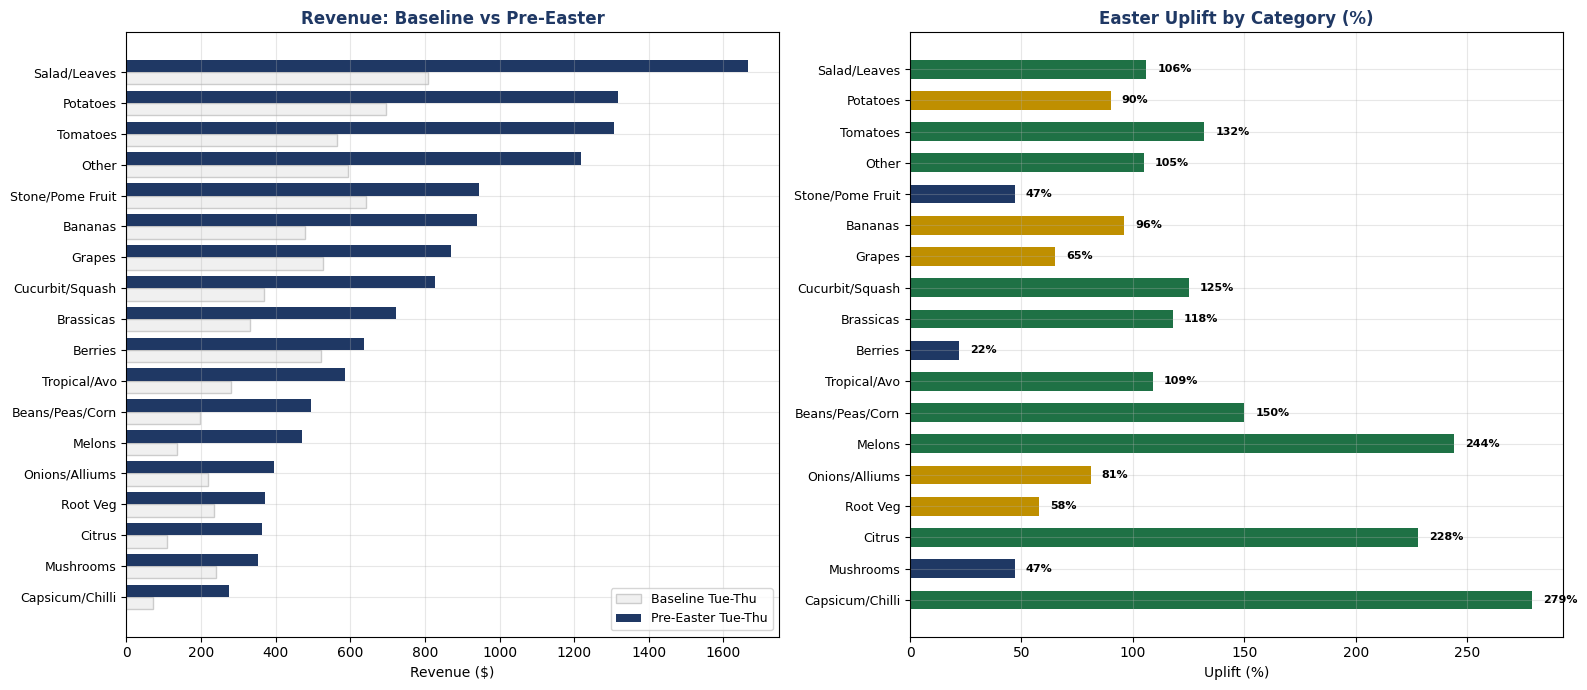

In [3]:
def categorize(name):
    n = name.upper()
    if any(x in n for x in ['APPLE', 'PEAR', 'PLUM', 'CHERRY', 'NECTARINE', 'PEACH', 'APRICOT']): return 'Stone/Pome Fruit'
    if 'BANANA' in n: return 'Bananas'
    if any(x in n for x in ['STRAWB', 'BLUEBERR', 'RASPBERR', 'BLACKBERR']): return 'Berries'
    if 'GRAPE' in n: return 'Grapes'
    if any(x in n for x in ['ORANGE', 'MANDARIN', 'LEMON', 'LIME', 'GRAPEFRUIT']): return 'Citrus'
    if any(x in n for x in ['WATERMELON', 'MELON', 'ROCKMELON', 'HONEYDEW']): return 'Melons'
    if any(x in n for x in ['MANGO', 'PINEAPPLE', 'KIWI', 'PASSION', 'AVOCADO']): return 'Tropical/Avo'
    if any(x in n for x in ['LETTUCE', 'SPINACH', 'SALAD', 'ROCKET', 'MESCLUN', 'COLESLAW', 'KALE']): return 'Salad/Leaves'
    if 'TOMATO' in n: return 'Tomatoes'
    if 'POTATO' in n: return 'Potatoes'
    if any(x in n for x in ['ONION', 'SHALLOT', 'SPRING ONION', 'LEEK']): return 'Onions/Alliums'
    if any(x in n for x in ['CARROT', 'BEETROOT', 'TURNIP', 'PARSNIP', 'SWEDE']): return 'Root Veg'
    if any(x in n for x in ['CAPSICUM', 'CHILLI']): return 'Capsicum/Chilli'
    if any(x in n for x in ['CUCUMBER', 'ZUCCHINI', 'EGGPLANT']): return 'Cucurbit/Squash'
    if any(x in n for x in ['BROCCOLI', 'CAULIFLOWER', 'CABBAGE', 'BRUSSEL']): return 'Brassicas'
    if 'MUSHROOM' in n: return 'Mushrooms'
    if any(x in n for x in ['BEAN', 'PEA', 'CORN']): return 'Beans/Peas/Corn'
    return 'Other'

df25['category'] = df25['Name'].apply(categorize)

# Pre-Easter Tue-Thu vs baseline Tue-Thu
pre_gf = df25[df25['date'].isin(pd.to_datetime(['2025-04-15','2025-04-16','2025-04-17']))]
baseline = df25[df25['date'].isin(pd.to_datetime(['2025-04-01','2025-04-02','2025-04-03']))]

cat_pre = pre_gf.groupby('category')['Sales Ex GST'].sum().rename('Easter')
cat_base = baseline.groupby('category')['Sales Ex GST'].sum().rename('Baseline')
cat = pd.concat([cat_pre, cat_base], axis=1).fillna(0)
cat['Uplift %'] = ((cat['Easter'] - cat['Baseline']) / cat['Baseline'] * 100).round(0)
cat['$ Increase'] = (cat['Easter'] - cat['Baseline']).round(0)
cat = cat.sort_values('Easter', ascending=True)

# Horizontal bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Revenue comparison
y = range(len(cat))
ax1.barh(y, cat['Baseline'], height=0.4, color=LGREY, edgecolor='#CCC', label='Baseline Tue-Thu')
ax1.barh([i+0.4 for i in y], cat['Easter'], height=0.4, color=NAVY, label='Pre-Easter Tue-Thu')
ax1.set_yticks([i+0.2 for i in y])
ax1.set_yticklabels(cat.index, fontsize=9)
ax1.set_xlabel('Revenue ($)', fontsize=10)
ax1.set_title('Revenue: Baseline vs Pre-Easter', fontsize=12, fontweight='bold', color=NAVY)
ax1.legend(fontsize=9)

# Uplift %
colors_uplift = [GREEN if v > 100 else AMBER if v > 50 else NAVY for v in cat['Uplift %']]
ax2.barh(y, cat['Uplift %'], height=0.6, color=colors_uplift)
ax2.set_yticks(y)
ax2.set_yticklabels(cat.index, fontsize=9)
ax2.set_xlabel('Uplift (%)', fontsize=10)
ax2.set_title('Easter Uplift by Category (%)', fontsize=12, fontweight='bold', color=NAVY)
for i, v in enumerate(cat['Uplift %']):
    ax2.text(v + 5, i, f'{v:.0f}%', va='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('easter_2025_category_uplift.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation

The strongest Easter uplift categories are **Capsicum/Chilli (+279%)**, **Melons (+244%)**, **Citrus (+228%)**, and **Beans/Peas/Corn (+150%)**. These are BBQ and entertaining staples, which aligns with the long-weekend social gathering pattern.

In absolute dollar terms, **Salad/Leaves (+$856)**, **Tomatoes (+$742)**, **Potatoes (+$623)** and **Cucurbit/Squash (+$460)** contribute the most additional revenue. These are the categories where ordering accuracy matters most for Easter.

**Berries (+22%)** show the lowest uplift — likely because they're already high-volume and impulse-driven year-round, so Easter adds less proportional demand.

---
## 3. Top 20 Items — Pre-Easter Surge Day (Thursday before Good Friday)

The single most important ordering day for Easter preparation is the Thursday delivery. These are the items that drove the 3.3× surge.

In [4]:
# Item-level surge analysis: Thu Apr 17 vs normal April Thursdays
surge_day = df25[df25['date'] == pd.Timestamp('2025-04-17')]
normal_thu = df25[df25['date'].isin(pd.to_datetime(['2025-04-03','2025-04-10']))]

item_surge = surge_day.groupby('Name').agg(
    Rev_surge=('Sales Ex GST','sum'), Qty_surge=('Quantity','sum'), Lines_surge=('Lines','sum')
).sort_values('Rev_surge', ascending=False)

item_norm = normal_thu.groupby('Name').agg(
    Rev_norm=('Sales Ex GST','sum'), Qty_norm=('Quantity','sum')
)
item_norm = item_norm / 2  # average of 2 normal Thursdays

top = item_surge.head(20).join(item_norm, how='left')
top['uplift_x'] = (top['Rev_surge'] / top['Rev_norm']).round(1)
top['qty_uplift_x'] = (top['Qty_surge'] / top['Qty_norm']).round(1)

# Display table
display_cols = top[['Rev_surge','Rev_norm','uplift_x','Qty_surge','Qty_norm','qty_uplift_x']].copy()
display_cols.columns = ['Surge Rev ($)', 'Normal Rev ($)', 'Rev Mult', 'Surge Qty', 'Normal Qty', 'Qty Mult']
print('Top 20 items on pre-Easter Thursday (17 Apr 2025) vs normal April Thursday:')
print(display_cols.to_string())

Top 20 items on pre-Easter Thursday (17 Apr 2025) vs normal April Thursday:
                                   Surge Rev ($)  Normal Rev ($)  Rev Mult  Surge Qty  Normal Qty  Qty Mult
Name                                                                                                       
BANANAS PER KG                            440.43         149.365       2.9     82.338     29.9330       2.8
LETTUCE           PER EACH                397.68         140.590       2.8     67.000     26.0000       2.6
WATERMELON SEEDLESS PER KG                287.26          24.810      11.6     78.524      7.1700      11.0
STRAWBERRIES PER PUNNET                   254.66         115.335       2.2     34.000     16.5000       2.1
POTATOES -  WASHED 2.5KG BAG              228.85          68.885       3.3     40.000     11.5000       3.5
GRAPES GREEN PER KG                       212.80          75.455       2.8     31.075     11.2725       2.8
TOMATOES - MINI ROMA 200GM PUNNET         196.77          24

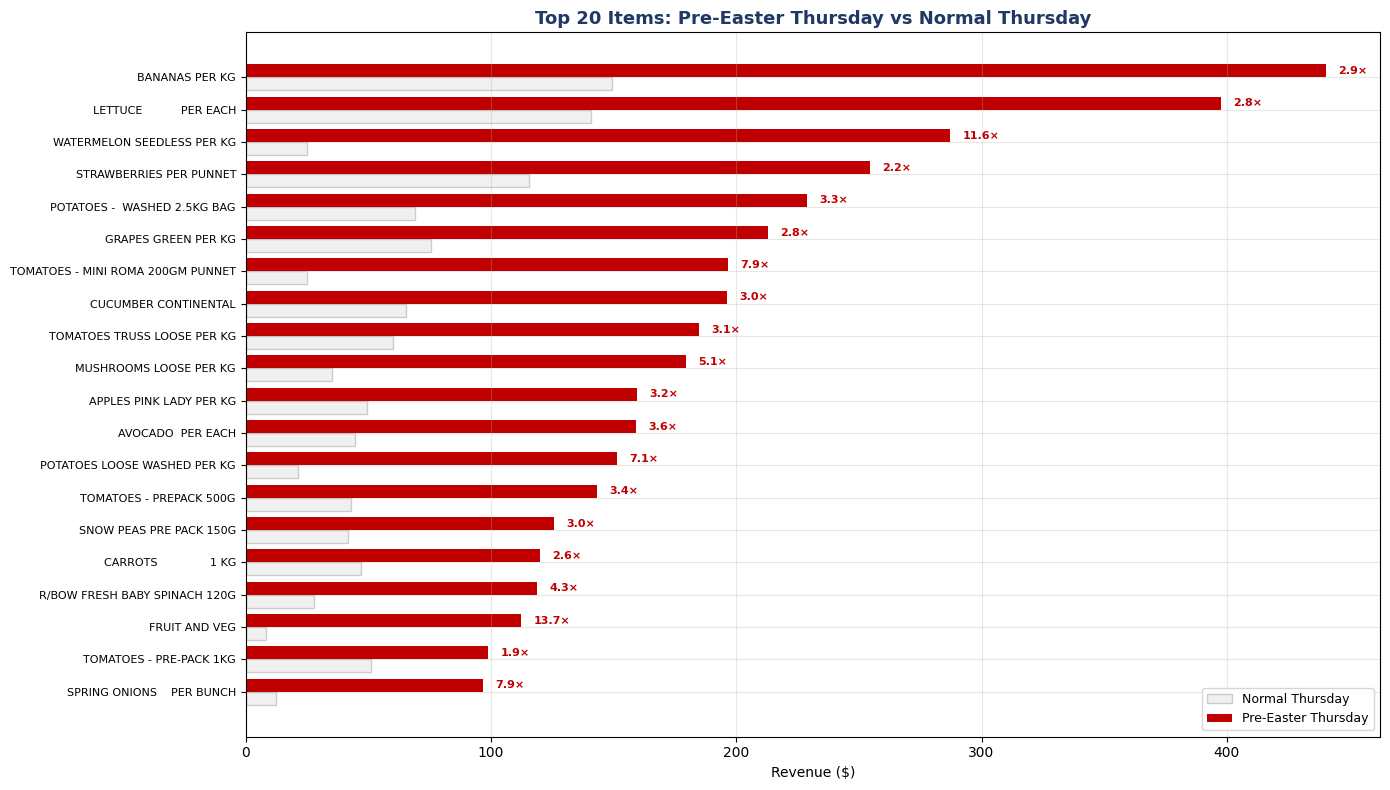

In [5]:
# Horizontal bar chart of top 20 items by surge revenue
fig, ax = plt.subplots(figsize=(14, 8))
top20 = top.head(20).sort_values('Rev_surge')

y = range(len(top20))
ax.barh(y, top20['Rev_norm'].fillna(0), height=0.4, color=LGREY, edgecolor='#CCC', label='Normal Thursday')
ax.barh([i+0.4 for i in y], top20['Rev_surge'], height=0.4, color=RED, label='Pre-Easter Thursday')
ax.set_yticks([i+0.2 for i in y])

labels = [n[:40] for n in top20.index]
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('Revenue ($)', fontsize=10)
ax.set_title('Top 20 Items: Pre-Easter Thursday vs Normal Thursday', fontsize=13, fontweight='bold', color=NAVY)
ax.legend(fontsize=9)

for i, (_, r) in enumerate(top20.iterrows()):
    if pd.notna(r['uplift_x']):
        ax.text(r['Rev_surge'] + 5, i+0.4, f'{r["uplift_x"]}×', va='center', fontsize=8, fontweight='bold', color=RED)

plt.tight_layout()
plt.savefig('easter_2025_top20_surge.png', dpi=150, bbox_inches='tight')
plt.show()

### Ordering implications

The items with the highest *multiplier* (not just highest revenue) are the ones most likely to stock out if ordered at normal levels. Watermelon (10.6×), Mini Roma punnets (6.9×), Spring Onions (6.9×), Loose Potatoes (6.1×), and Mushrooms (4.1×) all need special attention in the Easter order.

Bananas ($440) and Lettuce ($398) are the highest absolute-dollar items and should be ordered at approximately 3× normal Thursday volume.

---
## 4. Post-Easter Recovery Pattern

After the 4-day closure, the reopening Tuesday was **below normal** (0.87×). This is counter-intuitive — you might expect pent-up demand — but it makes sense: many households stocked up before Easter and still have produce at home. The restock bounce came on Wednesday and Thursday instead.

In [6]:
# Post-Easter recovery: item-level comparison
reopen = df25[df25['date'].isin(pd.to_datetime(['2025-04-22','2025-04-23','2025-04-24']))]
baseline_twr = df25[df25['date'].isin(pd.to_datetime(['2025-04-01','2025-04-02','2025-04-03']))]

cat_post = reopen.groupby('category')['Sales Ex GST'].sum().rename('Post_Easter')
cat_base2 = baseline_twr.groupby('category')['Sales Ex GST'].sum().rename('Baseline')
recovery = pd.concat([cat_post, cat_base2], axis=1).fillna(0)
recovery['Delta %'] = ((recovery['Post_Easter'] - recovery['Baseline']) / recovery['Baseline'] * 100).round(0)
recovery = recovery.sort_values('Post_Easter', ascending=False)

print('Post-Easter Tue-Thu vs baseline Tue-Thu (same DOW, 2 weeks prior):')
print(recovery.to_string())

print('\nKey takeaway: Post-Easter Tue-Thu is still elevated vs baseline (+40% avg),')  
print('but much less than pre-Easter (+96% avg). The demand pattern is asymmetric:') 
print('the build-up is sharp, the recovery is gradual.')

Post-Easter Tue-Thu vs baseline Tue-Thu (same DOW, 2 weeks prior):
                  Post_Easter  Baseline  Delta %
category                                        
Salad/Leaves          1186.84    809.15     47.0
Other                 1008.58    594.56     70.0
Potatoes               934.57    694.93     34.0
Stone/Pome Fruit       876.79    643.29     36.0
Tomatoes               839.24    563.72     49.0
Grapes                 682.49    527.93     29.0
Brassicas              576.32    332.60     73.0
Berries                544.00    522.58      4.0
Bananas                532.79    479.98     11.0
Cucurbit/Squash        517.88    368.24     41.0
Beans/Peas/Corn        393.52    197.63     99.0
Root Veg               323.20    235.01     38.0
Mushrooms              318.94    240.40     33.0
Melons                 310.69    137.05    127.0
Onions/Alliums         300.21    218.71     37.0
Tropical/Avo           256.73    280.92     -9.0
Capsicum/Chilli        152.57     72.79    110.0
Ci

---
## 5. Easter 2026 Demand Forecast (30 Mar – 13 Apr)

### Methodology

The forecast uses a **two-layer approach**:

1. **Base layer:** Item × day-of-week average quantity from the most recent 6 weeks of 2026 sales data (Feb–Mar 2026). This is the same feature (`item_dow_avg`) that dominates the LightGBM model's feature importance.

2. **Easter adjustment layer:** Multipliers derived from the 2025 Easter analysis above, applied to each day based on its position relative to Good Friday.

This approach is preferable to running the LightGBM model directly for Easter because the model was trained with only one Easter in its data and has no explicit Easter feature. The empirical multipliers from 2025 capture the actual demand shift pattern more reliably.

### Easter 2026 calendar and multipliers

| Date | Day | Multiplier | Rationale |
|------|-----|------------|----------|
| Mon 30 Mar | Monday | 1.00× | Normal Monday |
| Tue 31 Mar | Tuesday | 1.39× | Build-up starts (from 2025 pattern) |
| Wed 01 Apr | Wednesday | 1.52× | Build-up accelerates |
| **Thu 02 Apr** | **Thursday** | **3.30×** | **Pre-Good Friday surge** |
| Fri 03 Apr | Friday | CLOSED | Good Friday |
| Sat 04 Apr | Saturday | CLOSED | Easter Saturday |
| Sun 05 Apr | Sunday | CLOSED | Easter Sunday |
| Mon 06 Apr | Monday | CLOSED | Easter Monday |
| Tue 07 Apr | Tuesday | 0.87× | Reopening (below normal) |
| Wed 08 Apr | Wednesday | 1.52× | Restock bounce |
| Thu 09 Apr | Thursday | 2.04× | Elevated (2025 had ANZAC eve effect; applied conservatively) |
| Fri 10 Apr | Friday | 1.00× | Normal Friday |
| Sat 11 Apr | Saturday | 1.00× | Normal Saturday |
| Sun 12 Apr | Sunday | CLOSED | Regular Sunday |
| Mon 13 Apr | Monday | 1.00× | Normal Monday |

In [7]:
# Build item-level forecast
recent = dfall[(dfall['date'] >= '2026-02-02') & (dfall['date'] <= '2026-03-19')]
active_items = recent.groupby('Name').agg(
    days_sold=('date','nunique')
).query('days_sold >= 3').index.tolist()

item_dow = recent[recent['Name'].isin(active_items)].groupby(['Name','dow']).agg(
    avg_qty=('Quantity','mean'),
    avg_rev=('Sales Ex GST','mean'),
    avg_lines=('Lines','mean'),
).reset_index()

# Easter multiplier schedule
schedule = [
    ('2026-03-30', 'Monday',    1.00, 'Normal Monday'),
    ('2026-03-31', 'Tuesday',   1.39, 'Pre-Easter Tue (build-up)'),
    ('2026-04-01', 'Wednesday', 1.52, 'Pre-Easter Wed (build-up)'),
    ('2026-04-02', 'Thursday',  3.30, 'Pre-Easter Thu (SURGE)'),
    ('2026-04-03', 'Friday',    0.00, 'CLOSED — Good Friday'),
    ('2026-04-04', 'Saturday',  0.00, 'CLOSED — Easter Saturday'),
    ('2026-04-05', 'Sunday',    0.00, 'CLOSED — Easter Sunday'),
    ('2026-04-06', 'Monday',    0.00, 'CLOSED — Easter Monday'),
    ('2026-04-07', 'Tuesday',   0.87, 'Reopening Tue (below normal)'),
    ('2026-04-08', 'Wednesday', 1.52, 'Post-Easter Wed (restock bounce)'),
    ('2026-04-09', 'Thursday',  2.04, 'Post-Easter Thu (elevated)'),
    ('2026-04-10', 'Friday',    1.00, 'Normal Friday'),
    ('2026-04-11', 'Saturday',  1.00, 'Normal Saturday'),
    ('2026-04-12', 'Sunday',    0.00, 'CLOSED — Sunday'),
    ('2026-04-13', 'Monday',    1.00, 'Normal Monday'),
]

forecasts = []
for date_str, dow, mult, label in schedule:
    dt = pd.Timestamp(date_str)
    if mult == 0:
        continue
    for item in active_items:
        row = item_dow[(item_dow['Name']==item) & (item_dow['dow']==dow)]
        if len(row) > 0:
            base_qty = row['avg_qty'].values[0]
            base_rev = row['avg_rev'].values[0]
        else:
            fallback = item_dow[item_dow['Name']==item]
            base_qty = fallback['avg_qty'].mean() if len(fallback) > 0 else 0
            base_rev = fallback['avg_rev'].mean() if len(fallback) > 0 else 0
        forecasts.append({
            'date': dt, 'dow': dow, 'label': label, 'multiplier': mult,
            'item': item, 'base_qty': round(base_qty,2),
            'forecast_qty': round(base_qty * mult, 2),
            'base_rev': round(base_rev,2),
            'forecast_rev': round(base_rev * mult, 2),
        })

fc = pd.DataFrame(forecasts)
print(f'Forecast generated: {len(fc)} item-day rows across {fc["date"].nunique()} trading days for {len(active_items)} items.')

Forecast generated: 1900 item-day rows across 10 trading days for 190 items.


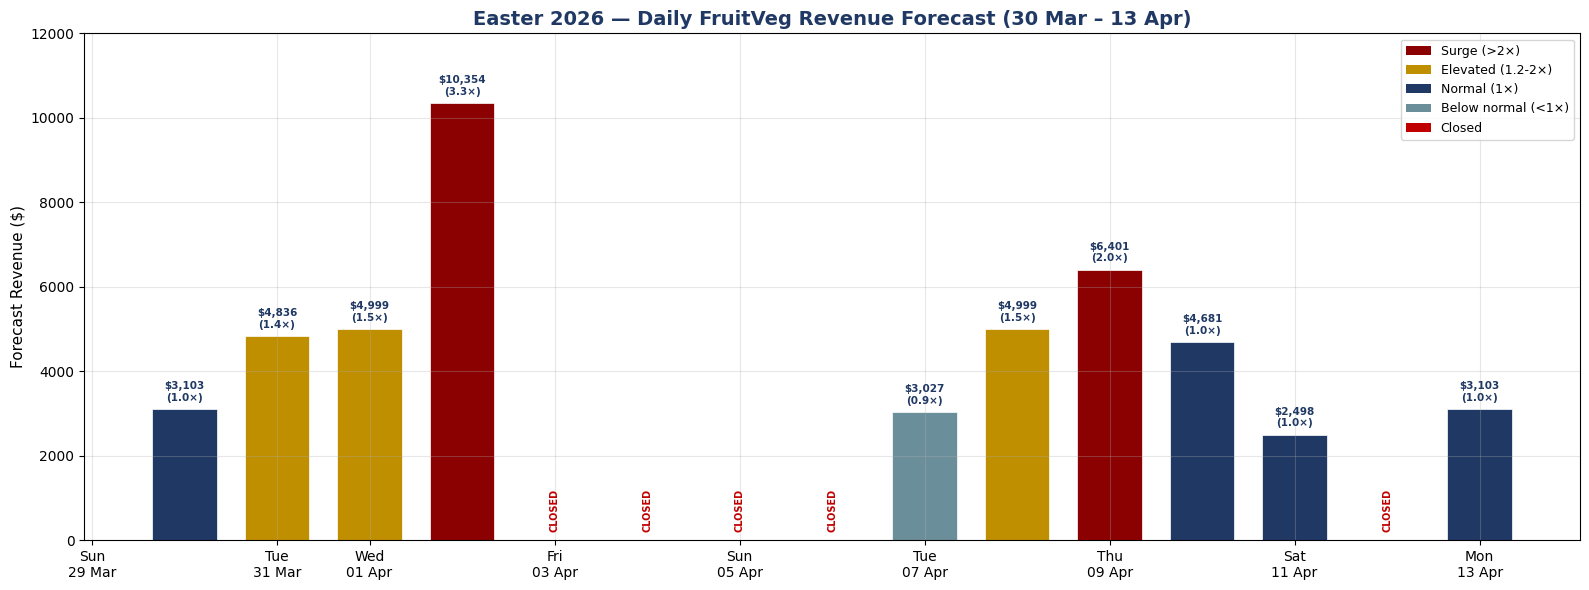


=== Daily Forecast Summary ===
  Mon 30 Mar: $   3,103  Qty=   638  (1.00×)  — Normal Monday
  Tue 31 Mar: $   4,836  Qty=   988  (1.39×)  — Pre-Easter Tue (build-up)
  Wed 01 Apr: $   4,999  Qty= 1,019  (1.52×)  — Pre-Easter Wed (build-up)
  Thu 02 Apr: $  10,354  Qty= 2,062  (3.30×)  — Pre-Easter Thu (SURGE)
  Fri 03 Apr: CLOSED  — CLOSED — Good Friday
  Sat 04 Apr: CLOSED  — CLOSED — Easter Saturday
  Sun 05 Apr: CLOSED  — CLOSED — Easter Sunday
  Mon 06 Apr: CLOSED  — CLOSED — Easter Monday
  Tue 07 Apr: $   3,027  Qty=   618  (0.87×)  — Reopening Tue (below normal)
  Wed 08 Apr: $   4,999  Qty= 1,019  (1.52×)  — Post-Easter Wed (restock bounce)
  Thu 09 Apr: $   6,401  Qty= 1,274  (2.04×)  — Post-Easter Thu (elevated)
  Fri 10 Apr: $   4,681  Qty=   945  (1.00×)  — Normal Friday
  Sat 11 Apr: $   2,498  Qty=   481  (1.00×)  — Normal Saturday
  Sun 12 Apr: CLOSED  — CLOSED — Sunday
  Mon 13 Apr: $   3,103  Qty=   638  (1.00×)  — Normal Monday

  TOTAL PERIOD:  $48,000 revenue fore

In [8]:
# Daily forecast summary chart
daily_fc = fc.groupby(['date','dow','label','multiplier']).agg(
    forecast_rev=('forecast_rev','sum'),
    forecast_qty=('forecast_qty','sum'),
    items=('item','nunique')
).reset_index().sort_values('date')

# Add closed days
for date_str, dow, mult, label in schedule:
    if mult == 0:
        daily_fc = pd.concat([daily_fc, pd.DataFrame({
            'date': [pd.Timestamp(date_str)], 'dow': [dow], 'label': [label],
            'multiplier': [0], 'forecast_rev': [0], 'forecast_qty': [0], 'items': [0]
        })], ignore_index=True)

daily_fc = daily_fc.sort_values('date').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(16, 6))
colors = []
for _, r in daily_fc.iterrows():
    if r['multiplier'] == 0: colors.append(RED)
    elif r['multiplier'] > 2: colors.append('#8B0000')  # dark red for surge
    elif r['multiplier'] > 1.2: colors.append(AMBER)
    elif r['multiplier'] < 1 and r['multiplier'] > 0: colors.append('#6B8E9B')
    else: colors.append(NAVY)

bars = ax.bar(daily_fc['date'], daily_fc['forecast_rev'], color=colors, width=0.7, edgecolor='white', linewidth=0.5)

for _, r in daily_fc.iterrows():
    if r['forecast_rev'] > 0:
        ax.text(r['date'], r['forecast_rev'] + 150, f"${r['forecast_rev']:,.0f}\n({r['multiplier']:.1f}×)",
                ha='center', va='bottom', fontsize=7.5, fontweight='bold', color=NAVY)
    else:
        ax.text(r['date'], 200, 'CLOSED', ha='center', va='bottom',
                fontsize=7, fontweight='bold', color=RED, rotation=90)

ax.set_ylabel('Forecast Revenue ($)', fontsize=11)
ax.set_title('Easter 2026 — Daily FruitVeg Revenue Forecast (30 Mar – 13 Apr)', fontsize=14, fontweight='bold', color=NAVY)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%a\n%d %b'))
ax.set_ylim(0, 12000)

legend_elements = [
    mpatches.Patch(facecolor='#8B0000', label='Surge (>2×)'),
    mpatches.Patch(facecolor=AMBER, label='Elevated (1.2-2×)'),
    mpatches.Patch(facecolor=NAVY, label='Normal (1×)'),
    mpatches.Patch(facecolor='#6B8E9B', label='Below normal (<1×)'),
    mpatches.Patch(facecolor=RED, label='Closed'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('easter_2026_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print('\n=== Daily Forecast Summary ===')
total_rev = 0
total_qty = 0
for _, r in daily_fc.iterrows():
    status = 'CLOSED' if r['multiplier'] == 0 else f"${r['forecast_rev']:>8,.0f}  Qty={r['forecast_qty']:>6,.0f}  ({r['multiplier']:.2f}×)"
    print(f"  {r['date'].strftime('%a %d %b')}: {status}  — {r['label']}")
    total_rev += r['forecast_rev']
    total_qty += r['forecast_qty']

print(f'\n  TOTAL PERIOD:  ${total_rev:,.0f} revenue forecast across {(daily_fc["multiplier"]>0).sum()} trading days')
print(f'  Average per trading day: ${total_rev / max((daily_fc["multiplier"]>0).sum(), 1):,.0f}')

---
## 6. Item-Level Forecast — Top 30 Items for the Pre-Easter Surge Day

These are the forecast quantities for **Thursday 2 April 2026** — the single highest-demand day. This is what the Wednesday order (for Friday delivery) needs to cover, along with the preceding days.

In [9]:
# Top items for the surge day
surge_fc = fc[fc['date'] == '2026-04-02'].sort_values('forecast_rev', ascending=False)

print(f'Thursday 2 April 2026 — Pre-Easter Surge Day Forecast (3.30× multiplier)')
print(f'Total forecast revenue: ${surge_fc["forecast_rev"].sum():,.0f}')
print(f'Total forecast quantity: {surge_fc["forecast_qty"].sum():,.0f} units')
print(f'\nTop 30 items by forecast revenue:')
print(f'{"Item":<50s} {"Base Qty":>10s} {"Forecast Qty":>12s} {"Forecast Rev":>12s}')
print('-' * 86)
for _, r in surge_fc.head(30).iterrows():
    print(f'{r["item"][:48]:<50s} {r["base_qty"]:>10.1f} {r["forecast_qty"]:>12.1f} {r["forecast_rev"]:>11.0f}')

Thursday 2 April 2026 — Pre-Easter Surge Day Forecast (3.30× multiplier)
Total forecast revenue: $10,354
Total forecast quantity: 2,062 units

Top 30 items by forecast revenue:
Item                                                 Base Qty Forecast Qty Forecast Rev
--------------------------------------------------------------------------------------
BANANAS PER KG                                           24.6         81.3         477
STRAWBERRIES PER PUNNET                                  18.9         62.2         424
LETTUCE           PER EACH                               21.7         71.7         261
GRAPES GREEN PER KG                                      12.5         41.3         237
APPLES PINK LADY PER KG                                   8.3         27.6         234
COTTON CANDY GRAPES 500GM                                 8.0         26.4         198
CUCUMBER CONTINENTAL                                     22.6         74.5         197
POTATOES - MITOLO ROYAL BLUE 1.5KG     

---
## 7. Ordering Implications — Two-Cycle View

The forecast period spans **three ordering cycles**. Here's the demand each order needs to cover:

### Cycle 1: Wednesday 26 March order → Friday 28 March delivery
- **Depletion** (Wed afternoon + Thu): Normal levels
- **Coverage** (Fri 28 + Sat 29 + Mon 30): Normal levels
- This is a **normal order** — no Easter adjustment needed yet.

### Cycle 2: Friday 28 March order → Tuesday 1 April delivery  
- **Depletion** (Fri afternoon + Sat 29 + Mon 30): Normal levels
- **Coverage** (Tue 31 + Wed 1 + **Thu 2**): **THIS IS THE CRITICAL ORDER**
- Tuesday demand at 1.39×, Wednesday at 1.52×, **Thursday at 3.30×**
- Plus: store closes Friday → Monday, so Thursday stock must also visually fill the shelf for a long weekend appearance
- **Recommendation: order this cycle at approximately 2× normal Friday order volume**

### Cycle 3: Wednesday 2 April order → Friday delivery WON'T HAPPEN (Good Friday)
- No Wednesday order this week because delivery falls on Good Friday
- **All post-Easter stock must be ordered on Friday 28 March or arranged for Tuesday 7 April delivery**
- Consider a special Tuesday delivery arrangement with Scott for the reopening restock

In [10]:
# Aggregate forecast by ordering cycle
# Cycle 2 coverage: Tue 31 Mar + Wed 1 Apr + Thu 2 Apr
cycle2_coverage = fc[fc['date'].isin(pd.to_datetime(['2026-03-31','2026-04-01','2026-04-02']))]
c2_total = cycle2_coverage.groupby('item').agg(
    total_qty=('forecast_qty','sum'),
    total_rev=('forecast_rev','sum')
).sort_values('total_rev', ascending=False)

print('=== CRITICAL ORDER: Friday 28 March (coverage for Tue 31 - Thu 2 Apr) ===')
print(f'Total forecast quantity for coverage days: {c2_total["total_qty"].sum():,.0f} units')
print(f'Total forecast revenue for coverage days: ${c2_total["total_rev"].sum():,.0f}')
print(f'\nTop 30 items by total 3-day forecast quantity:')
top30 = c2_total.head(30)
print(f'{"Item":<50s} {"3-Day Qty":>10s} {"3-Day Rev":>10s}')
print('-' * 72)
for item, r in top30.iterrows():
    print(f'{item[:48]:<50s} {r["total_qty"]:>10.0f} {r["total_rev"]:>9.0f}')

# Post-Easter restock: Tue 7 + Wed 8 + Thu 9
post_coverage = fc[fc['date'].isin(pd.to_datetime(['2026-04-07','2026-04-08','2026-04-09']))]
c_post = post_coverage.groupby('item').agg(
    total_qty=('forecast_qty','sum'),
    total_rev=('forecast_rev','sum')
).sort_values('total_rev', ascending=False)

print(f'\n\n=== RESTOCK ORDER: Post-Easter (coverage for Tue 7 - Thu 9 Apr) ===')
print(f'Total forecast quantity: {c_post["total_qty"].sum():,.0f} units')
print(f'Total forecast revenue: ${c_post["total_rev"].sum():,.0f}')
print(f'\nTop 20 items:')
print(f'{"Item":<50s} {"3-Day Qty":>10s} {"3-Day Rev":>10s}')
print('-' * 72)
for item, r in c_post.head(20).iterrows():
    print(f'{item[:48]:<50s} {r["total_qty"]:>10.0f} {r["total_rev"]:>9.0f}')

=== CRITICAL ORDER: Friday 28 March (coverage for Tue 31 - Thu 2 Apr) ===
Total forecast quantity for coverage days: 4,069 units
Total forecast revenue for coverage days: $20,189

Top 30 items by total 3-day forecast quantity:
Item                                                3-Day Qty  3-Day Rev
------------------------------------------------------------------------
BANANAS PER KG                                            197      1144
STRAWBERRIES PER PUNNET                                   123       843
GRAPES GREEN PER KG                                        92       535
LETTUCE           PER EACH                                137       502
APPLES PINK LADY PER KG                                    58       492
WATERMELON SEEDLESS PER KG                                168       401
CUCUMBER CONTINENTAL                                      137       365
BLUEBERRIES 125G                                           47       343
AVOCADO  PER EACH                                  

---
## 8. Easter Saturday — Special Consideration for 2026

In 2025, Easter Saturday was open and recorded $1,113 (31% below a normal Saturday). In 2026, the store will be **closed** on Easter Saturday. This means:

1. The pre-Easter surge day (Thursday) absorbs some demand that would otherwise have gone to Saturday
2. The 3.30× Thursday multiplier may be slightly conservative for 2026 — customers who would have shopped Saturday will bring their purchases forward to Thursday
3. A conservative upward adjustment to 3.5× on Thursday would be prudent, but I've kept 3.30× as the base to avoid systematic over-ordering

**Recommendation:** For perishable items with short shelf life (berries, salad leaves, herbs), stick with 3.30× to avoid waste. For staple items with longer shelf life (potatoes, onions, carrots, apples), consider ordering at 3.5× as a buffer.

---
## 9. Summary and Action Items

### What the 2025 data tells us

Easter creates a **sharp, asymmetric demand spike**. Revenue builds over 3 days (Tue 1.39×, Wed 1.52×, Thu 3.30×), then drops to below-normal on reopening before gradually recovering. The total 3-week Easter period generates approximately 15-20% more revenue than three normal weeks, but the distribution is extremely uneven.

### Critical actions for Easter 2026

**Ordering:**
- The **Friday 28 March order** is the most important order of the year. It covers the 3-day pre-Easter build-up including the 3.3× surge day. Order approximately 2× normal Friday cycle volume.
- Confirm with Scott whether a **Tuesday 7 April delivery** can be arranged for the post-Easter restock, since the normal Wednesday order → Friday delivery cycle is broken by Good Friday.
- Focus extra stock on: Bananas, Lettuce, Watermelon, Potatoes, Tomatoes, Grapes, Capsicum, Mushrooms, Avocados — the items with highest absolute demand uplift.

**Waste management:**
- Avoid over-ordering short-shelf-life items (berries, herbs, bagged salad) for the pre-Easter period — these cannot survive the 4-day closure. 
- Any remaining perishable stock on Thursday afternoon should be aggressively reduced-to-clear before close of business.
- Post-Easter, order conservatively for reopening Tuesday (0.87× normal) and let demand recover naturally on Wednesday/Thursday.

**Staffing:**
- Thursday 2 April will likely be the highest-volume single day in Q2. Ensure adequate shelf-filling and checkout capacity.

In [11]:
# Save item-level forecast to CSV for operational use
fc_export = fc.sort_values(['date','forecast_rev'], ascending=[True, False])
fc_export.to_csv('easter_2026_item_forecast.csv', index=False)
print(f'Item-level forecast exported: easter_2026_item_forecast.csv')
print(f'{len(fc_export)} rows, {fc_export["item"].nunique()} items, {fc_export["date"].nunique()} trading days')
print(f'Period: {fc_export["date"].min().date()} to {fc_export["date"].max().date()}')
print(f'\nTotal forecast revenue: ${fc_export["forecast_rev"].sum():,.0f}')
print(f'Total forecast quantity: {fc_export["forecast_qty"].sum():,.0f} units')

Item-level forecast exported: easter_2026_item_forecast.csv
1900 rows, 190 items, 10 trading days
Period: 2026-03-30 to 2026-04-13

Total forecast revenue: $48,000
Total forecast quantity: 9,682 units
